In [1]:
import pandas as pd
import numpy as np 

# Importations pour la construction du modèle
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Lambda

# Importation pour la transformation sur les images
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation

# Importation pour utiliser un modèle pre entrainé
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from keras.optimizers import Adam

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory

from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Importation pour les visualisations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, precision_score, recall_score
from metrics import MacroMetricsCallback

#from models.gradcam import GradCAM
#from models.gradcam import show_gradcam

#import random

print("Opération terminée")

Opération terminée


1. Chargement des images

In [2]:
chemin="/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_split"

train_ds = image_dataset_from_directory(
    directory=chemin+"/train_augmented/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=True,
   color_mode='rgb'
    
)

test_ds = image_dataset_from_directory(
    directory=chemin+"/test/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
   color_mode='rgb'
    
)

val_ds = image_dataset_from_directory(
    directory=chemin+"/validation/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
    
)


Found 33336 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.
Found 2083 files belonging to 4 classes.


2026-07-21 11:31:45.351983: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-07-21 11:31:45.352017: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-21 11:31:45.352020: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1784626305.352201  129086 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784626305.352622  129086 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
print(train_ds.class_names)
print(val_ds.class_names)
print(test_ds.class_names)

for X_batch, y_batch in train_ds.take(1):
    print("Images :", X_batch.shape)
    print("Labels :", y_batch.shape)

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Images : (32, 224, 224, 3)
Labels : (32,)


2026-07-21 11:31:49.429168: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
#Prétraitement des images pour la compatibilité avec le modèle EfficienNet
train_ds=train_ds.map(lambda x,y: (preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y: (preprocess_input(x),y))
tes_ds=test_ds.map(lambda x,y: (preprocess_input(x),y))

In [5]:
for X_batch, y_batch in train_ds.take(1):
    print("Images :", X_batch.shape)
    print("Labels :", y_batch.shape)

Images : (32, 224, 224, 3)
Labels : (32,)


2026-07-21 11:31:55.566043: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2. Visualisation du jeu de données

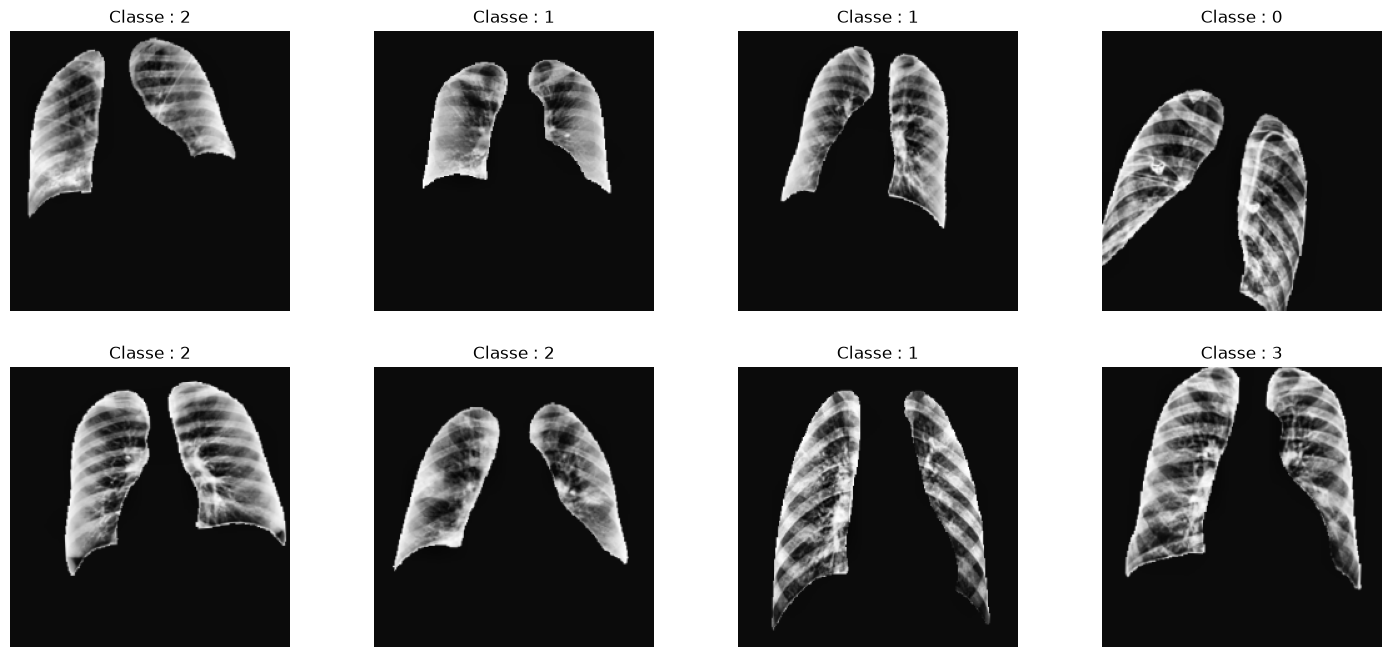

In [6]:
number_of_image=8

fig=plt.figure (figsize=(18,8))

for images, label in train_ds.take(1):
    for i in range(number_of_image):
        plt.subplot(2,4,i+1)
        indice=np.random.randint(len(label))
        plt.imshow(images[indice].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(f"Classe : {label[i].numpy()}")


plt.show()

3. Chargement du modèle

In [7]:
#Choix du device
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
base_model=EfficientNetB0(weights="imagenet", include_top=False)

#Gel des couches

base_model.trainable = False

base_model

<Functional name=efficientnetb0, built=True>

In [9]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
inputs=Input(shape=(224, 224, 3), name="Input")

x=base_model(inputs)

x=GlobalAveragePooling2D()(x)
x=Dropout(0.3)(x)
x=Dense(units=128, activation="relu")(x)
x=Dropout(0.3)(x)
outputs=Dense(units=4, activation="softmax", name="output_layer")(x)

model=Model(inputs=inputs, outputs=outputs)

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

4. Création de callbacks et d'un early stopping

In [12]:
early_stopping=EarlyStopping(monitor="val_loss",
                             patience=5,
                             min_delta=0.01,
                             mode="min",
                             verbose=1)

reduce_learning_rate=ReduceLROnPlateau(monitor="val_loss",
                           factor=0.1,
                           patience=3,
                           cooldown=4,
                           min_delta=0.01)

In [13]:
#Création d'une fonction pour suivre le f1-score à chaque epoch
from metrics import MacroMetricsCallback

macro_metrics = MacroMetricsCallback(train_ds, val_ds)
    

5. Compilation et entraînement du modèle

In [14]:
optimizer=Adam(1e-4)

In [15]:
#Compilation du modèle

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [16]:
#Entraînement du modèle

model_history=model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[reduce_learning_rate, early_stopping, macro_metrics])

Epoch 1/30


/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-21 11:33:30.439658: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.6773 - loss: 0.8123

2026-07-21 11:43:01.732820: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.7172 | Val F1 : 0.6925
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 592s 564ms/step - accuracy: 0.6773 - loss: 0.8123 - val_accuracy: 0.7753 - val_loss: 0.5848 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7172 - val_f1_macro: 0.6925
Epoch 2/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7374 - loss: 0.6701
Train F1 : 0.7553 | Val F1 : 0.7394
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 580s 557ms/step - accuracy: 0.7374 - loss: 0.6701 - val_accuracy: 0.7984 - val_loss: 0.5342 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7553 - val_f1_macro: 0.7394
Epoch 3/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.7545 - loss: 0.6308

...


Train F1 : 0.7681 | Val F1 : 0.7574
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 576s 553ms/step - accuracy: 0.7545 - loss: 0.6308 - val_accuracy: 0.8046 - val_loss: 0.5078 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7681 - val_f1_macro: 0.7574
Epoch 4/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7644 - loss: 0.6080
Train F1 : 0.7683 | Val F1 : 0.7493
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 582s 558ms/step - accuracy: 0.7644 - loss: 0.6080 - val_accuracy: 0.8060 - val_loss: 0.5060 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7683 - val_f1_macro: 0.7493
Epoch 5/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.7690 - loss: 0.5892
Train F1 : 0.7827 | Val F1 : 0.7793
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 589s 565ms/step - accuracy: 0.7690 - loss: 0.5892 - val_accuracy: 0.8157 - val_loss: 0.4884 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7827 - val_f1_macro: 0.7793
Epoch 6/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7728 - loss: 0.5830
Train F1 : 0.7900 | Val 

2026-07-21 12:41:16.141460: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.7897 | Val F1 : 0.7881
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 586s 563ms/step - accuracy: 0.7755 - loss: 0.5754 - val_accuracy: 0.8224 - val_loss: 0.4794 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7897 - val_f1_macro: 0.7881
Epoch 8/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7809 - loss: 0.5668
Train F1 : 0.7945 | Val F1 : 0.7814
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 580s 557ms/step - accuracy: 0.7809 - loss: 0.5668 - val_accuracy: 0.8166 - val_loss: 0.4770 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7945 - val_f1_macro: 0.7814
Epoch 9/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7826 - loss: 0.5588
Train F1 : 0.7970 | Val F1 : 0.7924
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 580s 557ms/step - accuracy: 0.7826 - loss: 0.5588 - val_accuracy: 0.8224 - val_loss: 0.4712 - learning_rate: 1.0000e-04 - train_f1_macro: 0.7970 - val_f1_macro: 0.7924
Epoch 10/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7837 - loss: 0.5542
Train F1 : 0.7932 | Val

2026-07-21 14:02:58.234945: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Train F1 : 0.8021 | Val F1 : 0.7983
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 642s 616ms/step - accuracy: 0.7876 - loss: 0.5444 - val_accuracy: 0.8257 - val_loss: 0.4628 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8021 - val_f1_macro: 0.7983
Epoch 16/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7886 - loss: 0.5443
Train F1 : 0.8008 | Val F1 : 0.7986
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 591s 568ms/step - accuracy: 0.7886 - loss: 0.5443 - val_accuracy: 0.8257 - val_loss: 0.4634 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8008 - val_f1_macro: 0.7986
Epoch 17/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7887 - loss: 0.5444
Train F1 : 0.8029 | Val F1 : 0.7990
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 579s 556ms/step - accuracy: 0.7887 - loss: 0.5444 - val_accuracy: 0.8257 - val_loss: 0.4616 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8029 - val_f1_macro: 0.7990
Epoch 17: early stopping


In [17]:
model.save("cnn_EfficientNet.keras")
model.save_weights("cnn_EfficientNet.weights.h5")
print("modèle et poids sauvegardés")

modèle et poids sauvegardés


6. Évaluation du modèle

In [20]:
train_acc=model_history.history["accuracy"]
val_acc=model_history.history["val_accuracy"]

train_loss=model_history.history["loss"]
val_loss=model_history.history["val_loss"]

train_f1=model_history.history["train_f1_macro"]
val_f1=model_history.history["val_f1_macro"]

nb_epochs=len(train_acc)
print(nb_epochs)

17


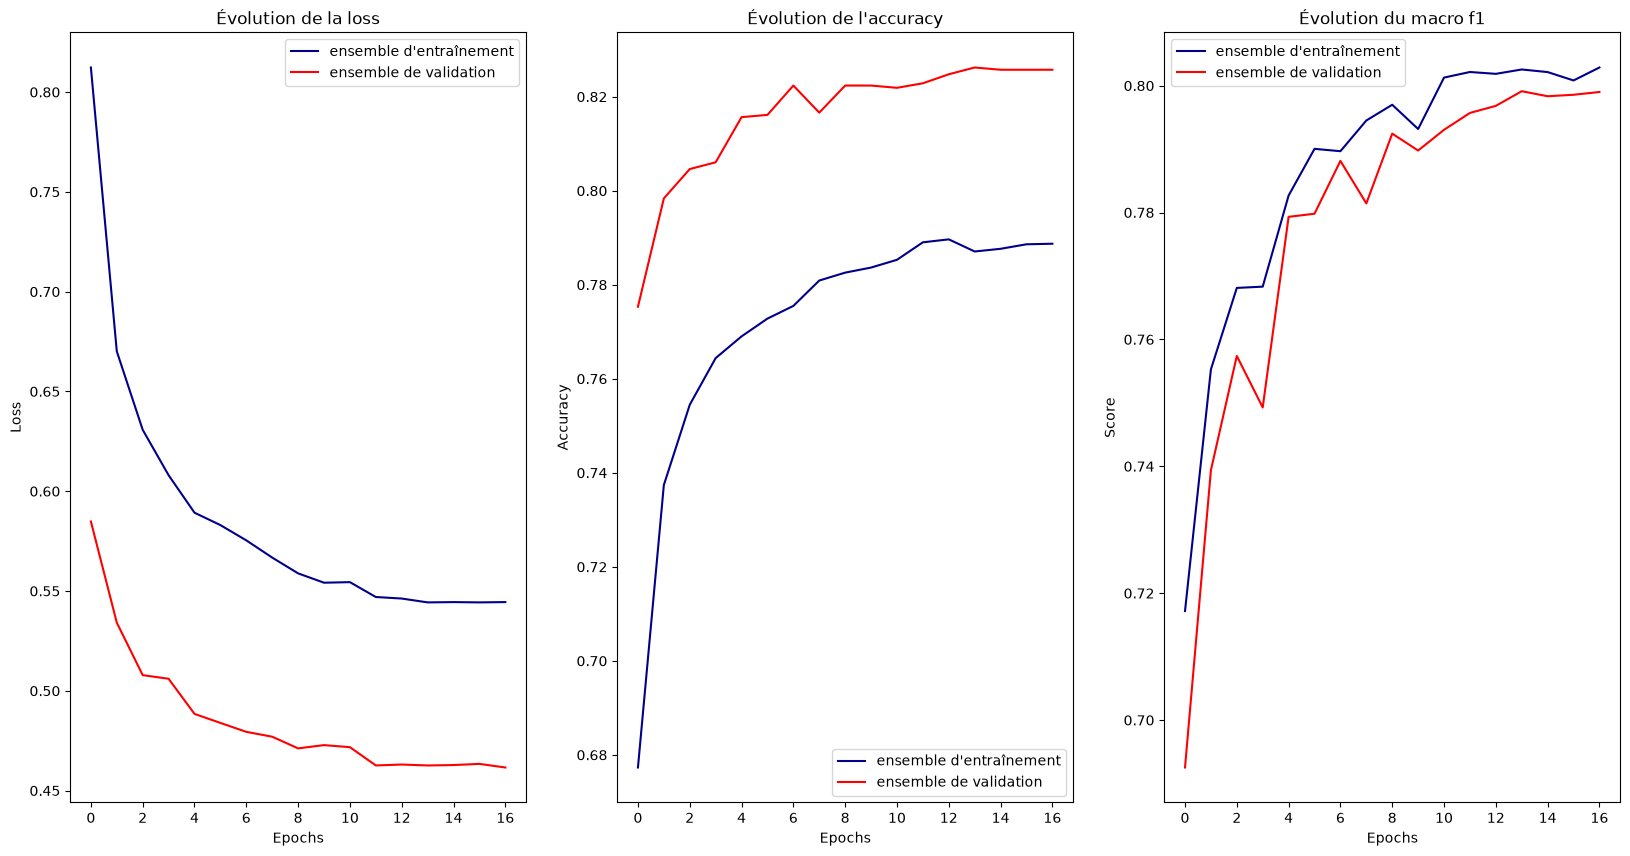

In [26]:
fig=plt.figure(figsize=(20,10))

plt.subplot(1,3,1)

plt.plot(np.arange(nb_epochs), train_loss, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_loss, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.title("Évolution de la loss")


plt.subplot(1,3,2)

plt.plot(np.arange(nb_epochs), train_acc, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_acc, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Évolution de l'accuracy")

plt.subplot(1,3,3)

plt.plot(np.arange(nb_epochs), train_f1, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs), val_f1, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()

plt.title("Évolution du macro f1")

plt.show()

In [27]:
y_pred = model.predict(test_ds)
y_pred_class = y_pred.argmax(axis=1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step


In [28]:
y_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)
print(y_test_class)

[0 0 0 ... 3 3 3]


In [29]:
print(classification_report(y_test_class, y_pred_class))

              precision    recall  f1-score   support

           0       0.78      0.55      0.65       337
           1       0.83      0.79      0.81       599
           2       0.84      0.95      0.89      1014
           3       0.96      0.87      0.91       134

    accuracy                           0.83      2084
   macro avg       0.85      0.79      0.82      2084
weighted avg       0.83      0.83      0.83      2084



[[187  63  87   0]
 [ 40 475  84   0]
 [ 14  34 961   5]
 [  0   2  15 117]]


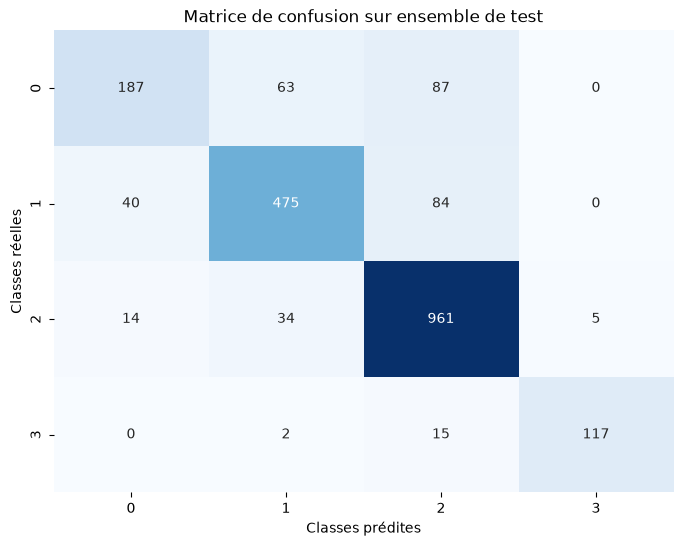

In [30]:
conf_matrix = confusion_matrix(y_test_class, y_pred_class)
    
print (conf_matrix)

plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(conf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel("Classes réelles")
plt.xlabel("Classes prédites")
plt.show()

7. Fine tuning

In [31]:
#Degel des couches inférieures : On ne dégel que le dernier bloc de convolution (block7a)
for i, layer in enumerate(base_model.layers):
    if layer.name.startswith('block7'):
            break
    freeze_from = i
for layer in model.layers[freeze_from:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [32]:
early_stopping=EarlyStopping(monitor="val_loss",
                             patience=8,
                             min_delta=0.001,
                             mode="min",
                             verbose=1)

reduce_learning_rate=ReduceLROnPlateau(monitor="val_loss",
                           factor=0.1,
                           patience=3,
                           cooldown=4,
                           min_delta=0.01)

In [33]:
fine_tuned_history=model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[reduce_learning_rate, early_stopping, macro_metrics])

model.save("cnn_fine_tuned_EfficientNet.keras")
print("fine tuned modèle sauvegardé")

Epoch 1/30


/opt/anaconda3/envs/Liora/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7897 - loss: 0.5450
Train F1 : 0.8028 | Val F1 : 0.7960
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 603s 574ms/step - accuracy: 0.7897 - loss: 0.5450 - val_accuracy: 0.8243 - val_loss: 0.4610 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8028 - val_f1_macro: 0.7960
Epoch 2/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.7909 - loss: 0.5394
Train F1 : 0.8034 | Val F1 : 0.7959
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 579s 555ms/step - accuracy: 0.7909 - loss: 0.5394 - val_accuracy: 0.8229 - val_loss: 0.4608 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8034 - val_f1_macro: 0.7959
Epoch 3/30
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7893 - loss: 0.5425
Train F1 : 0.8024 | Val F1 : 0.7976
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 580s 557ms/step - accuracy: 0.7893 - loss: 0.5425 - val_accuracy: 0.8253 - val_loss: 0.4633 - learning_rate: 1.0000e-05 - train_f1_macro: 0.8024 - val_f1_macro: 0.7976
Epoch 4/30
1042/1042 ━━━━━━━━━━━━━━━

8. Évaluation du modèle après fine tuning

In [34]:
train_acc_fine=fine_tuned_history.history["accuracy"]
val_acc_fine=fine_tuned_history.history["val_accuracy"]

train_loss_fine=fine_tuned_history.history["loss"]
val_loss_fine=fine_tuned_history.history["val_loss"]

train_f1_fine=fine_tuned_history.history["train_f1_macro"]
val_f1_fine=fine_tuned_history.history["val_f1_macro"]

nb_epochs_fine=len(train_acc_fine)
print(nb_epochs_fine)

9


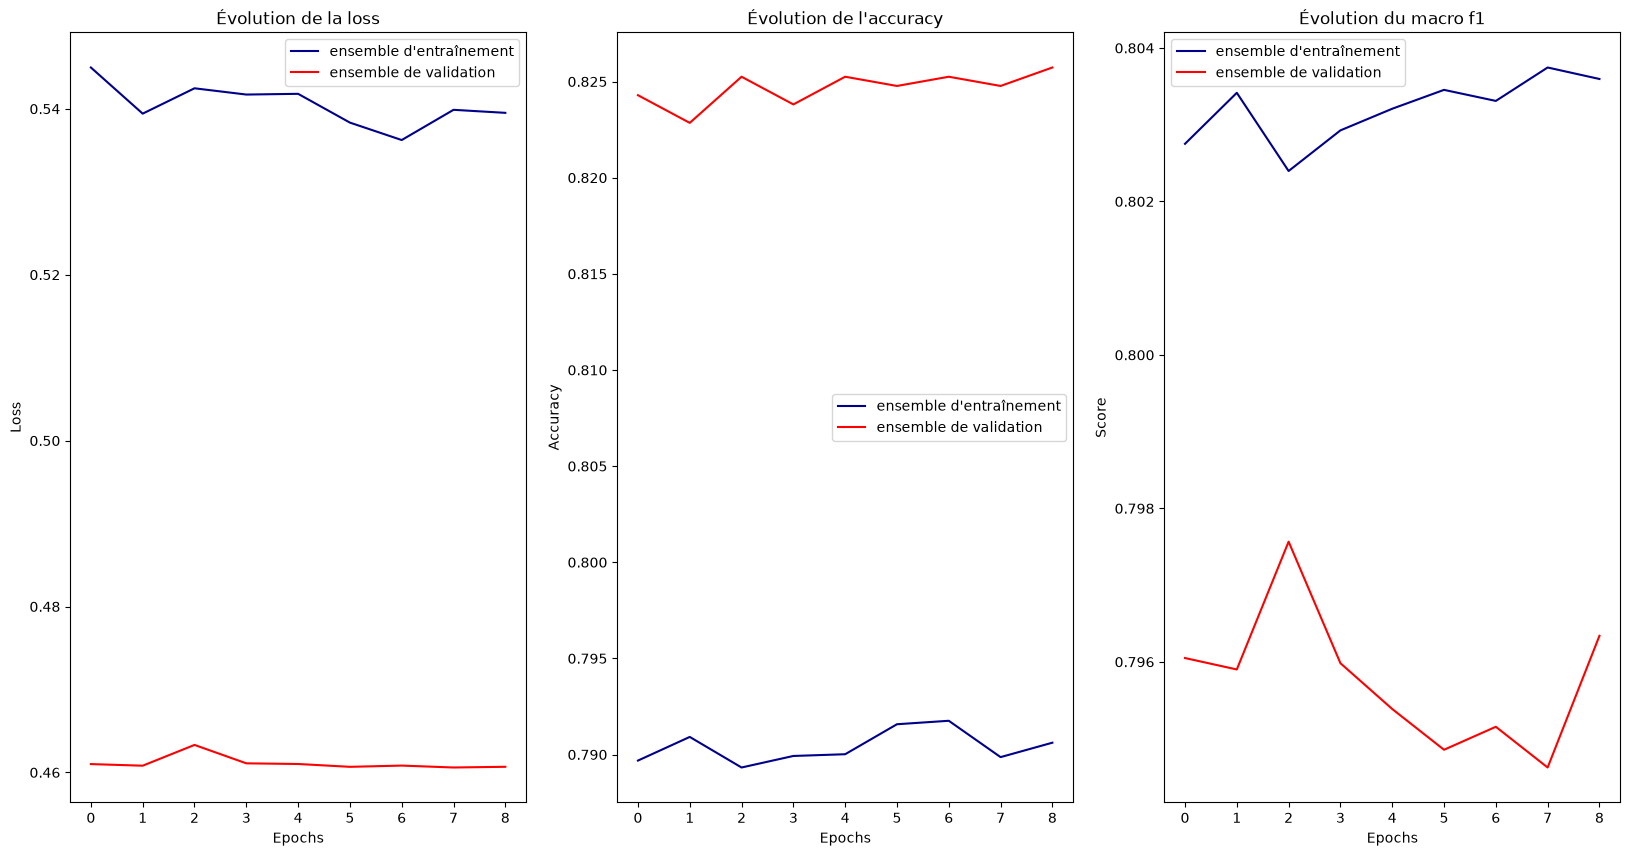

In [36]:
fig=plt.figure(figsize=(20,10))

plt.subplot(1,3,1)

plt.plot(np.arange(nb_epochs_fine), train_loss_fine, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs_fine), val_loss_fine, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.title("Évolution de la loss")


plt.subplot(1,3,2)

plt.plot(np.arange(nb_epochs_fine), train_acc_fine, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs_fine), val_acc_fine, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Évolution de l'accuracy")

plt.subplot(1,3,3)

plt.plot(np.arange(nb_epochs_fine), train_f1_fine, color="darkblue", label=["ensemble d'entraînement"])
plt.plot(np.arange(nb_epochs_fine), val_f1_fine, color="red", label=["ensemble de validation"])

plt.xlabel("Epochs")
plt.ylabel("Score")

plt.legend()

plt.title("Évolution du macro f1")

plt.show()

In [37]:
y_pred = model.predict(test_ds)
y_pred_class = y_pred.argmax(axis=1)

y_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)
print(y_test_class)

print(classification_report(y_test_class, y_pred_class))

66/66 ━━━━━━━━━━━━━━━━━━━━ 23s 293ms/step
[0 0 0 ... 3 3 3]
              precision    recall  f1-score   support

           0       0.78      0.55      0.65       337
           1       0.83      0.79      0.81       599
           2       0.84      0.95      0.89      1014
           3       0.95      0.89      0.92       134

    accuracy                           0.84      2084
   macro avg       0.85      0.80      0.82      2084
weighted avg       0.83      0.84      0.83      2084



[[187  63  87   0]
 [ 41 473  85   0]
 [ 14  33 961   6]
 [  0   2  15 117]]


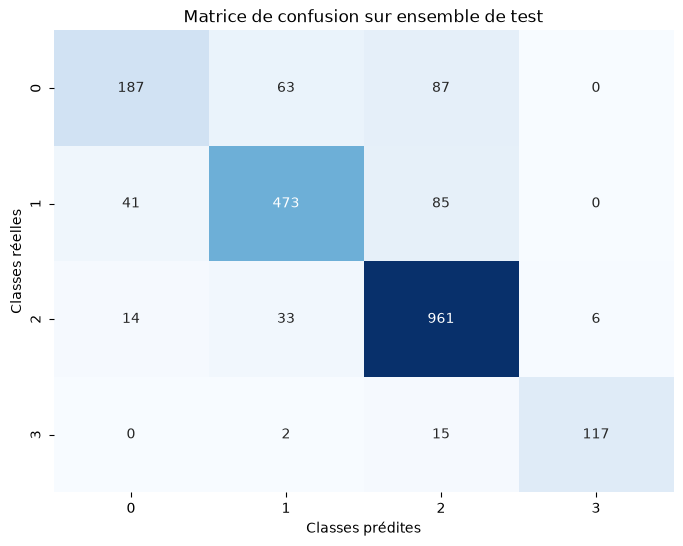

In [66]:
conf_matrix = confusion_matrix(y_test_class, y_pred_class)

print (conf_matrix)

plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(conf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel("Classes réelles")
plt.xlabel("Classes prédites")
plt.show()

9. Réentraînement du model avec class weight